<a href="https://colab.research.google.com/github/240264-sudo/AI-ML-lab/blob/main/AI_ML_LAB_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download(
    "sergionefedov/global-semiconductor-industry-2010-2026"
)
print("Path to dataset files:", path)

# List all files in the downloaded directory
files = os.listdir(path)
print("Files downloaded:", files)

# Find the target CSV file dynamically
csv_file = [f for f in files if f.endswith(".csv")][0]
file_path = os.path.join(path, csv_file)

# Load into pandas
df = pd.read_csv(file_path)

# Inspect columns and data types
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")

df.head()

100%|██████████| 19.1k/19.1k [00:00<00:00, 10.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sergionefedov/global-semiconductor-industry-2010-2026/versions/1
Files downloaded: ['chip_companies_financials.csv', 'fab_capacity.csv', 'export_controls.csv', 'ai_chip_market.csv', 'chip_prices.csv']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     617 non-null    int64  
 1   company_name             617 non-null    object 
 2   ticker                   617 non-null    object 
 3   country_iso3             617 non-null    object 
 4   segment                  617 non-null    object 
 5   revenue_usd_bn           617 non-null    float64
 6   operating_margin_pct     617 non-null    float64
 7   operating_income_usd_bn  617 non-null    float64
 8   rd_spend_usd_bn          617 non-null    float64
 9   capex

,year,company_name,ticker,country_iso3,segment,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,rd_spend_usd_bn,capex_usd_bn
0,2010,TSMC,TSM,TWN,foundry,13.42,36.9,4.95,1.07,6.04
1,2011,TSMC,TSM,TWN,foundry,16.32,42.8,6.99,1.31,7.35
2,2012,TSMC,TSM,TWN,foundry,17.56,36.1,6.34,1.40,7.90
3,2013,TSMC,TSM,TWN,foundry,21.36,39.1,8.34,1.71,9.61
4,2014,TSMC,TSM,TWN,foundry,23.93,37.4,8.96,1.91,10.77


DataFrame shape after dropping NaNs for ['rd_spend_usd_bn', 'capex_usd_bn', 'operating_margin_pct', 'revenue_usd_bn']: (617, 10)
Removed 109 rows due to outliers in features or target: 109 rows.
DataFrame shape after outlier removal: (508, 10)

Training set size (Multi): 406 samples
Testing set size (Multi): 102 samples

--- Multiple Linear Regression Results (with full preprocessing) ---
Intercept: 7.4557
Coefficient for rd_spend_usd_bn: 5.0200
Coefficient for capex_usd_bn: 1.6306
Coefficient for operating_margin_pct: -0.3356
R2 Score: 0.8778
Mean Squared Error (MSE): 4.9754
Root Mean Squared Error (RMSE): 2.2306


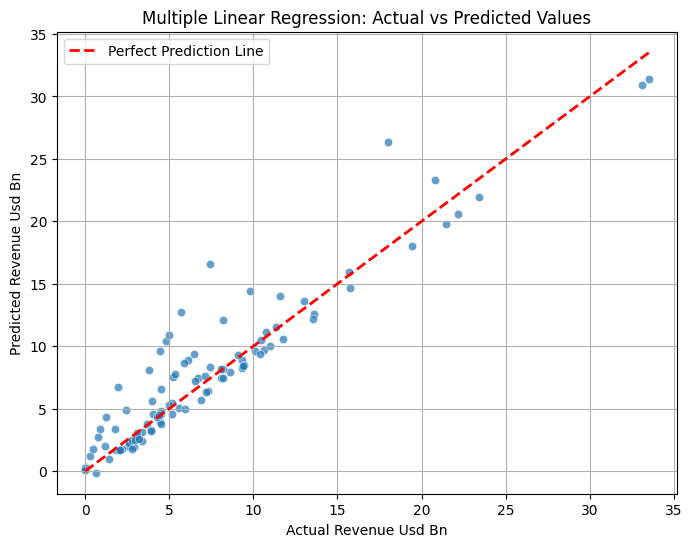

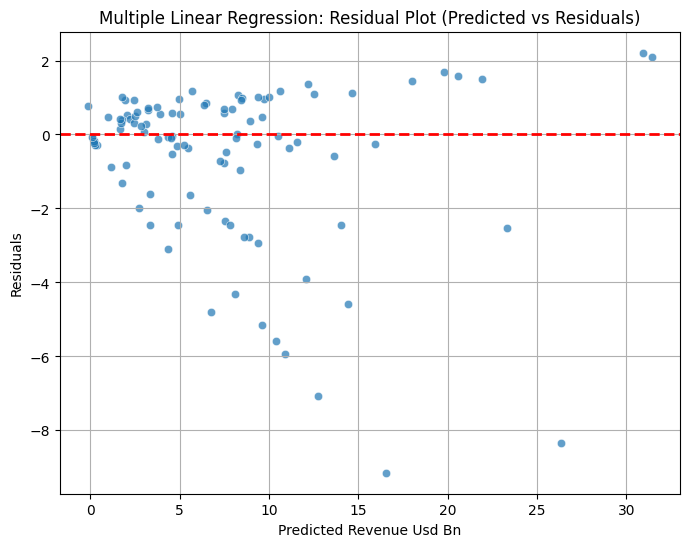

In [ ]:
# Select multiple numerical features
features = ["rd_spend_usd_bn", "capex_usd_bn", "operating_margin_pct"]
target = "revenue_usd_bn"

# Start with the DataFrame after initial general cleaning (e.g., duplicate removal from df_full_workflow)
# `df_full_workflow` is expected to be available from previous cells (cell da0be828).
processed_df_multi = df_full_workflow.copy()

# Clean missing values specifically for the selected features and target
processed_df_multi = processed_df_multi.dropna(subset=features + [target]).copy()
print(f"DataFrame shape after dropping NaNs for {features + [target]}: {processed_df_multi.shape}")

# Outlier Handling: Remove outliers using the IQR method for all selected features and target
initial_rows_after_nan_multi = processed_df_multi.shape[0]
outlier_condition_multi = pd.Series(True, index=processed_df_multi.index)

# Apply IQR filter for each feature and the target
for col in features + [target]:
    Q1 = processed_df_multi[col].quantile(0.25)
    Q3 = processed_df_multi[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_condition_multi = outlier_condition_multi & (processed_df_multi[col] >= lower_bound) & (processed_df_multi[col] <= upper_bound)

processed_df_multi = processed_df_multi[outlier_condition_multi]
print(f"Removed {initial_rows_after_nan_multi - processed_df_multi.shape[0]} rows due to outliers in features or target: {initial_rows_after_nan_multi - processed_df_multi.shape[0]} rows.")
print("DataFrame shape after outlier removal:", processed_df_multi.shape)

X_multi = processed_df_multi[features]
y_multi = processed_df_multi[target]

# Train-Test Split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)
print(f"\nTraining set size (Multi): {X_train_multi.shape[0]} samples")
print(f"Testing set size (Multi): {X_test_multi.shape[0]} samples")

# Feature Scaling
scaler_multi = StandardScaler()
X_train_scaled_multi = scaler_multi.fit_transform(X_train_multi)
X_test_scaled_multi = scaler_multi.transform(X_test_multi)

# Convert scaled arrays back to DataFrames for consistency and easier plotting/analysis
X_train_scaled_df_multi = pd.DataFrame(X_train_scaled_multi, columns=X_train_multi.columns, index=X_train_multi.index)
X_test_scaled_df_multi = pd.DataFrame(X_test_scaled_multi, columns=X_test_multi.columns, index=X_test_multi.index)

# Initialize and fit model
multi_model = LinearRegression()
multi_model.fit(X_train_scaled_df_multi, y_train_multi)

# Make predictions
y_pred_multi = multi_model.predict(X_test_scaled_df_multi)

# Output coefficients and evaluation metrics
print("\n--- Multiple Linear Regression Results (with full preprocessing) ---")
print(f"Intercept: {multi_model.intercept_:.4f}")
for col, coef in zip(features, multi_model.coef_):
    print(f"Coefficient for {col}: {coef:.4f}")

r2_multi = r2_score(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi) # Root Mean Squared Error

print(f"R2 Score: {r2_multi:.4f}")
print(f"Mean Squared Error (MSE): {mse_multi:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_multi:.4f}")

# Visualization for Multiple Linear Regression (Actual vs Predicted and Residual plots)

# Plot: Actual vs Predicted plot for Multiple Linear Regression
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_multi, y=y_pred_multi, alpha=0.7)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], '--r', linewidth=2, label='Perfect Prediction Line')
plt.xlabel(f"Actual {target.replace('_', ' ').title()}")
plt.ylabel(f"Predicted {target.replace('_', ' ').title()}")
plt.title('Multiple Linear Regression: Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Plot: Residual plot for Multiple Linear Regression
residuals_multi = y_test_multi - y_pred_multi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_multi, y=residuals_multi, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel(f"Predicted {target.replace('_', ' ').title()}")
plt.ylabel('Residuals')
plt.title('Multiple Linear Regression: Residual Plot (Predicted vs Residuals)')
plt.grid(True)
plt.show()

In [ ]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import kagglehub # Import kagglehub here to define path

# Redefine path to ensure dataset is accessible within this workflow
path = kagglehub.dataset_download("sergionefedov/global-semiconductor-industry-2010-2026")

# Reload the specific CSV file to ensure a clean start for the full workflow
file_path = os.path.join(path, "chip_companies_financials.csv")
df_full_workflow = pd.read_csv(file_path)

print("Original DataFrame Info:")
df_full_workflow.info()
print("\nOriginal DataFrame Shape:", df_full_workflow.shape)

# Check for missing values
print("\nMissing values before preprocessing:")
print(df_full_workflow.isnull().sum())

# Remove duplicates
initial_rows = df_full_workflow.shape[0]
df_full_workflow.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_rows - df_full_workflow.shape[0]} duplicate rows.")
print("DataFrame shape after removing duplicates:", df_full_workflow.shape)

# No explicit conversion to numeric needed as per df.info(), but this step is crucial if data types were 'object' for numeric columns.
# For example: df_full_workflow['some_column'] = pd.to_numeric(df_full_workflow['some_column'], errors='coerce')


100%|██████████| 19.1k/19.1k [00:00<00:00, 20.9MB/s]

Extracting files...
Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     617 non-null    int64  
 1   company_name             617 non-null    object 
 2   ticker                   617 non-null    object 
 3   country_iso3             617 non-null    object 
 4   segment                  617 non-null    object 
 5   revenue_usd_bn           617 non-null    float64
 6   operating_margin_pct     617 non-null    float64
 7   operating_income_usd_bn  617 non-null    float64
 8   rd_spend_usd_bn          617 non-null    float64
 9   capex_usd_bn             617 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 48.3+ KB

Original DataFrame Shape: (617, 10)

Missing values before preprocessing:
year                       0
company_name               0
ticker

DataFrame shape after dropping NaNs for 'rd_spend_usd_bn' and 'revenue_usd_bn': (617, 10)
Removed 72 rows due to outliers.
DataFrame shape after outlier removal: (545, 10)

Training set size (SLR): 436 samples
Testing set size (SLR): 109 samples

--- Simple Linear Regression Results (with full preprocessing) ---
Intercept: 8.6728
Coefficient for rd_spend_usd_bn: 6.8798
R2 Score: 0.7972
Mean Squared Error (MSE): 8.9773
Root Mean Squared Error (RMSE): 2.9962


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


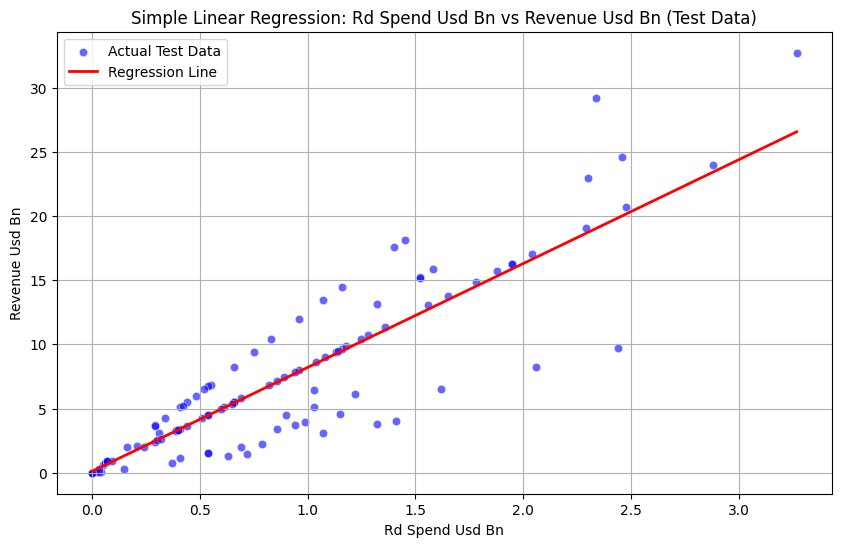

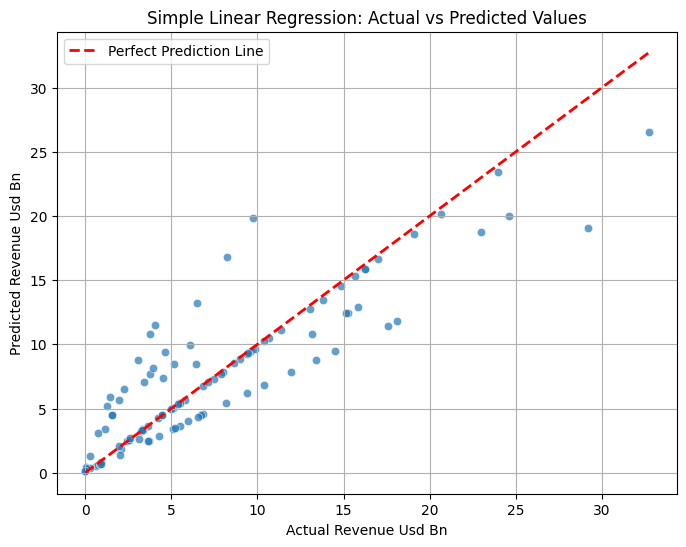

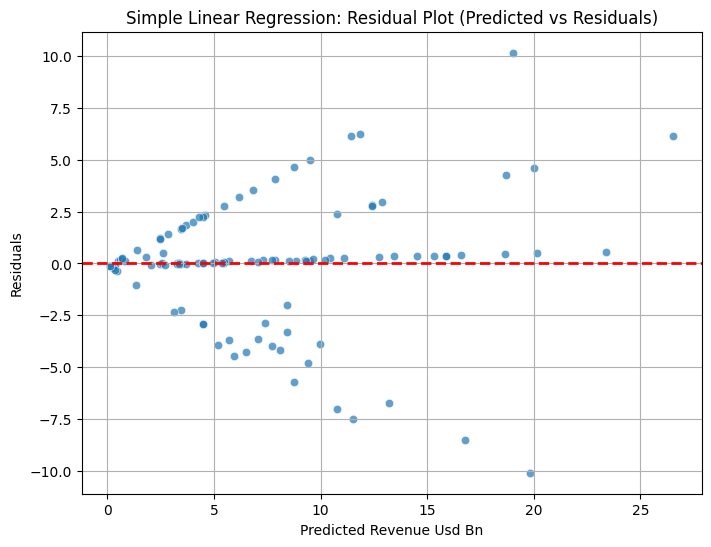

In [ ]:
# Define feature and target for Simple Linear Regression
feature_slr = "rd_spend_usd_bn"
target_slr = "revenue_usd_bn"

# Start with the DataFrame after initial general cleaning (e.g., duplicate removal from df_full_workflow)
processed_df_slr = df_full_workflow.copy()

# Clean missing values specifically for the selected feature and target
processed_df_slr = processed_df_slr.dropna(subset=[feature_slr, target_slr]).copy()
print(f"DataFrame shape after dropping NaNs for '{feature_slr}' and '{target_slr}': {processed_df_slr.shape}")

# Outlier Handling: Remove outliers using the IQR method for both feature and target
initial_rows_after_nan_slr = processed_df_slr.shape[0]

Q1_feat_slr = processed_df_slr[feature_slr].quantile(0.25)
Q3_feat_slr = processed_df_slr[feature_slr].quantile(0.75)
IQR_feat_slr = Q3_feat_slr - Q1_feat_slr
lower_bound_feat_slr = Q1_feat_slr - 1.5 * IQR_feat_slr
upper_bound_feat_slr = Q3_feat_slr + 1.5 * IQR_feat_slr

Q1_targ_slr = processed_df_slr[target_slr].quantile(0.25)
Q3_targ_slr = processed_df_slr[target_slr].quantile(0.75)
IQR_targ_slr = Q3_targ_slr - Q1_targ_slr
lower_bound_targ_slr = Q1_targ_slr - 1.5 * IQR_targ_slr
upper_bound_targ_slr = Q3_targ_slr + 1.5 * IQR_targ_slr

processed_df_slr = processed_df_slr[
    (processed_df_slr[feature_slr] >= lower_bound_feat_slr) & (processed_df_slr[feature_slr] <= upper_bound_feat_slr) &
    (processed_df_slr[target_slr] >= lower_bound_targ_slr) & (processed_df_slr[target_slr] <= upper_bound_targ_slr)
]
print(f"Removed {initial_rows_after_nan_slr - processed_df_slr.shape[0]} rows due to outliers.")
print("DataFrame shape after outlier removal:", processed_df_slr.shape)

X_slr = processed_df_slr[[feature_slr]]
y_slr = processed_df_slr[target_slr]

# Train-Test Split (80:20)
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)
print(f"\nTraining set size (SLR): {X_train_slr.shape[0]} samples")
print(f"Testing set size (SLR): {X_test_slr.shape[0]} samples")

# Feature Scaling
scaler_slr = StandardScaler()
X_train_scaled_slr = scaler_slr.fit_transform(X_train_slr)
X_test_scaled_slr = scaler_slr.transform(X_test_slr)

# Convert scaled arrays back to DataFrames for consistency
X_train_scaled_df_slr = pd.DataFrame(X_train_scaled_slr, columns=X_train_slr.columns, index=X_train_slr.index)
X_test_scaled_df_slr = pd.DataFrame(X_test_scaled_slr, columns=X_test_slr.columns, index=X_test_slr.index)

# Initialize and fit model
slr_model = LinearRegression()
slr_model.fit(X_train_scaled_df_slr, y_train_slr)

# Make predictions
y_pred_slr = slr_model.predict(X_test_scaled_df_slr)

# Output coefficients and evaluation metrics
print("\n--- Simple Linear Regression Results (with full preprocessing) ---")
print(f"Intercept: {slr_model.intercept_:.4f}")
print(f"Coefficient for {feature_slr}: {slr_model.coef_[0]:.4f}")

r2_slr = r2_score(y_test_slr, y_pred_slr)
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)

print(f"R2 Score: {r2_slr:.4f}")
print(f"Mean Squared Error (MSE): {mse_slr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_slr:.4f}")

# Visualizations for Simple Linear Regression

# Plot 1: Scatter plot of the original data with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_slr[feature_slr].values.flatten(), y=y_test_slr, color='blue', alpha=0.6, label='Actual Test Data')

# Plot the regression line using original (unscaled) X_test and predicted y
# Need to inverse transform the scaled X_test_slr or transform original X_test to get original scale for plotting line correctly
# A simpler way is to predict on the scaled data and then plot against original X_test for visualization clarity
original_X_test_scaled_for_plot = scaler_slr.transform(X_test_slr)
predicted_y_for_plot = slr_model.predict(original_X_test_scaled_for_plot)

# Sort for smooth line plot
sort_idx = np.argsort(X_test_slr[feature_slr].values.flatten())
plt.plot(X_test_slr[feature_slr].values.flatten()[sort_idx], predicted_y_for_plot[sort_idx], color='red', linewidth=2, label='Regression Line')

plt.xlabel(f"{feature_slr.replace('_', ' ').title()}")
plt.ylabel(f"{target_slr.replace('_', ' ').title()}")
plt.title(f"Simple Linear Regression: {feature_slr.replace('_', ' ').title()} vs {target_slr.replace('_', ' ').title()} (Test Data)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Actual vs Predicted plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_slr, y=y_pred_slr, alpha=0.7)
plt.plot([y_test_slr.min(), y_test_slr.max()], [y_test_slr.min(), y_test_slr.max()], '--r', linewidth=2, label='Perfect Prediction Line')
plt.xlabel(f"Actual {target_slr.replace('_', ' ').title()}")
plt.ylabel(f"Predicted {target_slr.replace('_', ' ').title()}")
plt.title('Simple Linear Regression: Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Residual plot
residuals_slr = y_test_slr - y_pred_slr
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_slr, y=residuals_slr, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel(f"Predicted {target_slr.replace('_', ' ').title()}")
plt.ylabel('Residuals')
plt.title('Simple Linear Regression: Residual Plot (Predicted vs Residuals)')
plt.grid(True)
plt.show()